In [1]:
# Cell 1 - Imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_ANALYTICS, BQ_CLUSTERING_TRACTS

In [2]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_CLUSTERING_TRACTS}"
client = bigquery.Client(project=GCS_PROJECT_ID)
# Exclude geometry
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df = client.query(query).to_arrow().to_pandas()
tract_df.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   tract_geoid                         83313 non-null  str    
 1   pop_ch_avg                          83313 non-null  float64
 2   pop_pctch_avg                       83313 non-null  float64
 3   estimated_census_housing_units      83313 non-null  int64  
 4   estimated_fcc_units                 83313 non-null  int64  
 5   pre_early_dev_parcels               83313 non-null  float64
 6   builder_developer_count             83313 non-null  float64
 7   landuse_change_count                83313 non-null  float64
 8   building_permit_count               83313 non-null  float64
 9   median_dist_nearest_hotspot         83313 non-null  float64
 10  median_dist_nearest_fiber_m         83313 non-null  float64
 11  pre_early_dev_parcels_bin           83313 non-null  

In [3]:
# NA treatment — same as clustering notebook
tract_df['pre_early_dev_parcels'] = tract_df['pre_early_dev_parcels'].fillna(0)
tract_df['builder_developer_count'] = tract_df['builder_developer_count'].fillna(0)
tract_df['building_permit_count'] = tract_df['building_permit_count'].fillna(0)
tract_df['landuse_change_count'] = tract_df['landuse_change_count'].fillna(0)
tract_df['cable_penetration'] = tract_df['cable_penetration'].fillna(0)
tract_df['fiber_opportunity_gap'] = tract_df['fiber_opportunity_gap'].fillna(1.0)

fiber_dist_cap = tract_df['median_dist_nearest_fiber_m'].quantile(0.99)
tract_df['median_dist_nearest_fiber_m'] = tract_df['median_dist_nearest_fiber_m'].fillna(fiber_dist_cap)

hotspot_cap = tract_df['median_dist_nearest_hotspot'].max() * 1.25
tract_df['median_dist_nearest_hotspot'] = tract_df['median_dist_nearest_hotspot'].fillna(hotspot_cap)

# Drop columns not used as features
cols_to_drop = [col for col in tract_df.columns 
                if col in ['tract_geoid', 'estimated_fcc_units', 'provider_competitive_landscape', 'cable_future_gap', 'cluster']
                or col.endswith('_bin')]

y = tract_df['cluster']
X = tract_df.drop(columns=cols_to_drop)

feature_cols = X.columns.tolist()
print(f"Target classes: {sorted(y.unique())}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Features (13): ['pop_ch_avg', 'pop_pctch_avg', 'estimated_census_housing_units', 'pre_early_dev_parcels', 'builder_developer_count', 'landuse_change_count', 'building_permit_count', 'median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m', 'cable_penetration', 'fiber_opportunity_gap', 'fiber_speed_top_tier', 'provider_competitive_landscape_ord']
X shape: (83313, 13), y shape: (83313,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      3071
           1       0.96      0.94      0.95      1264
           2       0.93      0.92      0.93      1476
           3       0.93      0.95      0.94      3351
           4       0.94      0.95      0.94      2096
           5       0.97      0.94      0.96       823
           6       0.91      0.92      0.92      2742
           7       0.95      0.92      0.94      1840

    accuracy                           0.94     16663
   macro avg       0.94      0.94      0.94     16663
weighted avg       0.94      0.94      0.94     16663



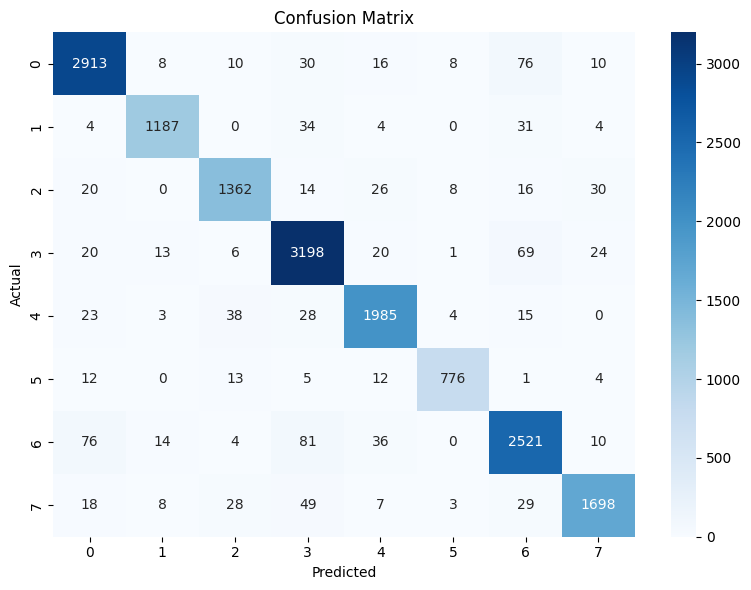

In [5]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()

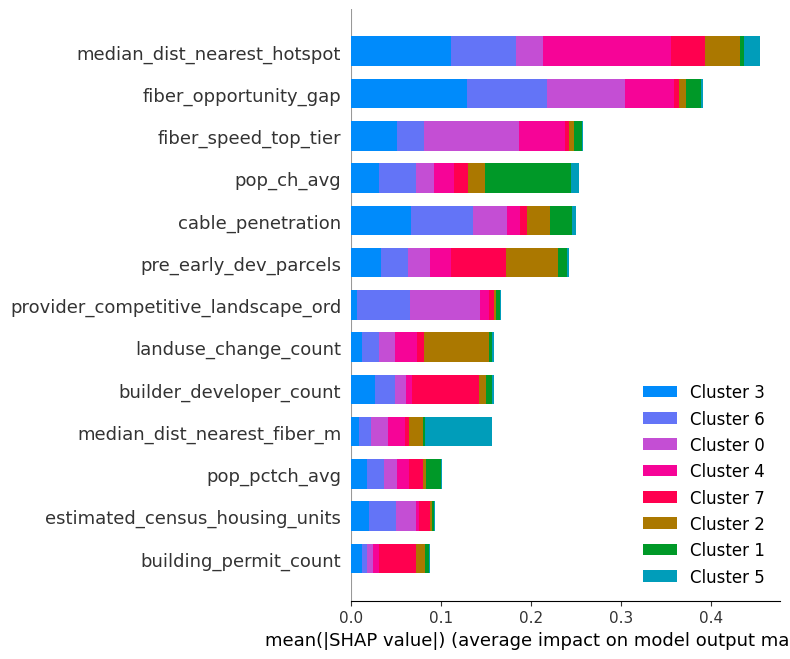

In [7]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Global feature importance (mean |SHAP| across all classes)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar", class_names=[f"Cluster {i}" for i in sorted(y.unique())])

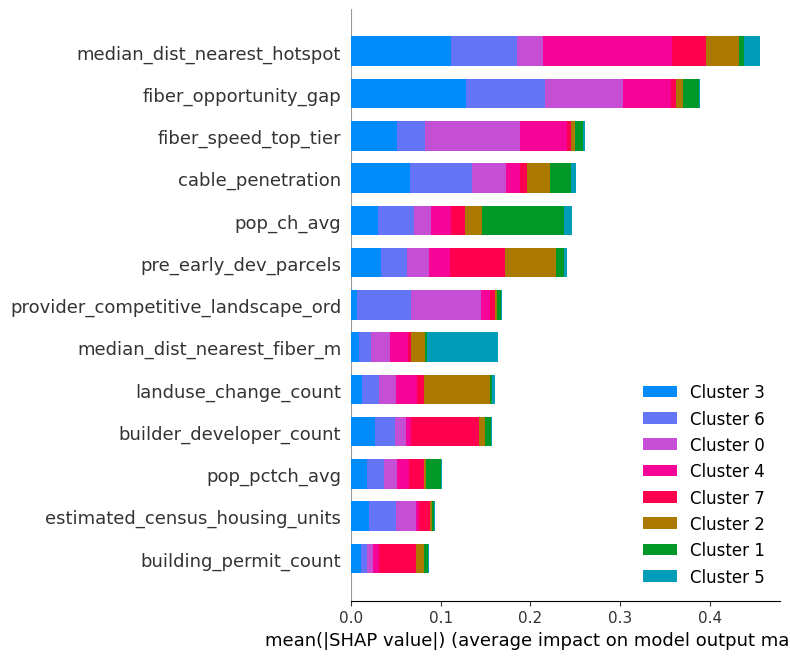

In [6]:
import shap

# Subsample for SHAP — full test set is unnecessarily slow
X_shap = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

# Global feature importance (mean |SHAP| across all classes)
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type="bar",
                  class_names=[f"Cluster {i}" for i in sorted(y.unique())])

In [12]:
print(shap_values)
print(f"shap_values[0].shape: {shap_values[0].shape}")
print(f"X_shap.shape: {X_shap.shape}")

[[[-6.87186448e-03 -3.58454411e-02 -9.23105583e-03 ... -4.38921514e-03
    1.55105534e-02  9.58143801e-03]
  [-5.85735745e-03 -5.27332296e-03  3.26052093e-04 ... -3.44592325e-04
    3.00295348e-03 -3.09951702e-03]
  [ 1.22062562e-02 -1.76662993e-03 -3.57540847e-04 ...  2.27019613e-04
   -2.27901518e-02 -1.11456876e-02]
  ...
  [-1.12993607e-01 -1.86258459e-02  1.69592938e-03 ... -1.43107202e-04
   -1.09799724e-01 -2.27172140e-03]
  [-9.92429925e-02  3.29420217e-03 -1.12179126e-03 ... -1.54606700e-04
   -1.80061610e-02  2.37453604e-03]
  [ 6.95595534e-04 -6.14554379e-05 -2.09884327e-04 ...  9.96813957e-06
   -7.97407921e-03 -7.95316991e-04]]

 [[-3.76790994e-03 -6.59693400e-02 -2.84954167e-02 ... -5.93700708e-03
    5.12597493e-02  4.51875771e-02]
  [-3.94456699e-03 -3.35902794e-03 -2.23248084e-04 ... -1.39752385e-04
    4.22251905e-03  6.05107349e-04]
  [-2.80711676e-02  3.21454139e-03 -8.19164538e-03 ... -1.00929461e-03
    1.86321087e-02  6.71673270e-02]
  ...
  [ 3.47017465e-02  1.1


--- Cluster 0 — Top features by mean |SHAP| ---
fiber_speed_top_tier                  0.1063
fiber_opportunity_gap                 0.0870
provider_competitive_landscape_ord    0.0784
cable_penetration                     0.0384
median_dist_nearest_hotspot           0.0293
pre_early_dev_parcels                 0.0247
estimated_census_housing_units        0.0220
median_dist_nearest_fiber_m           0.0206
pop_ch_avg                            0.0197
landuse_change_count                  0.0184
pop_pctch_avg                         0.0147
builder_developer_count               0.0122
building_permit_count                 0.0070



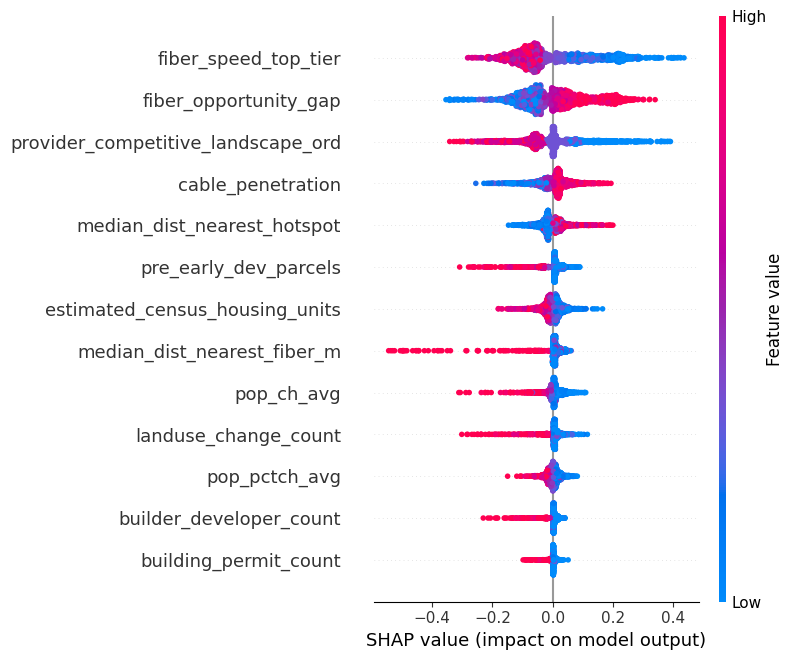


--- Cluster 1 — Top features by mean |SHAP| ---
pop_ch_avg                            0.0911
cable_penetration                     0.0243
fiber_opportunity_gap                 0.0171
pop_pctch_avg                         0.0167
pre_early_dev_parcels                 0.0091
fiber_speed_top_tier                  0.0089
builder_developer_count               0.0069
median_dist_nearest_hotspot           0.0045
building_permit_count                 0.0041
provider_competitive_landscape_ord    0.0040
landuse_change_count                  0.0031
estimated_census_housing_units        0.0024
median_dist_nearest_fiber_m           0.0023



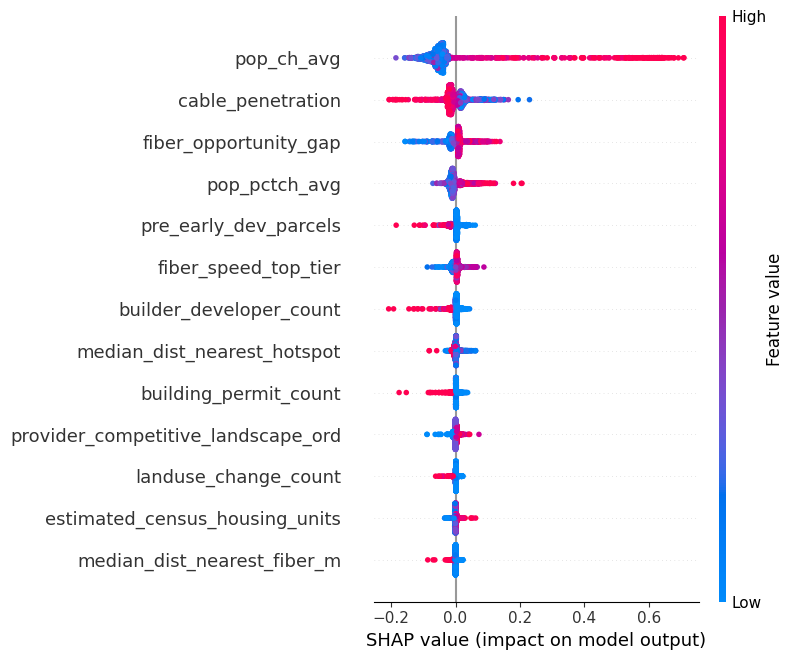


--- Cluster 2 — Top features by mean |SHAP| ---
landuse_change_count                  0.0731
pre_early_dev_parcels                 0.0575
median_dist_nearest_hotspot           0.0378
cable_penetration                     0.0258
pop_ch_avg                            0.0196
median_dist_nearest_fiber_m           0.0155
building_permit_count                 0.0092
fiber_opportunity_gap                 0.0083
builder_developer_count               0.0071
fiber_speed_top_tier                  0.0049
pop_pctch_avg                         0.0030
provider_competitive_landscape_ord    0.0026
estimated_census_housing_units        0.0023



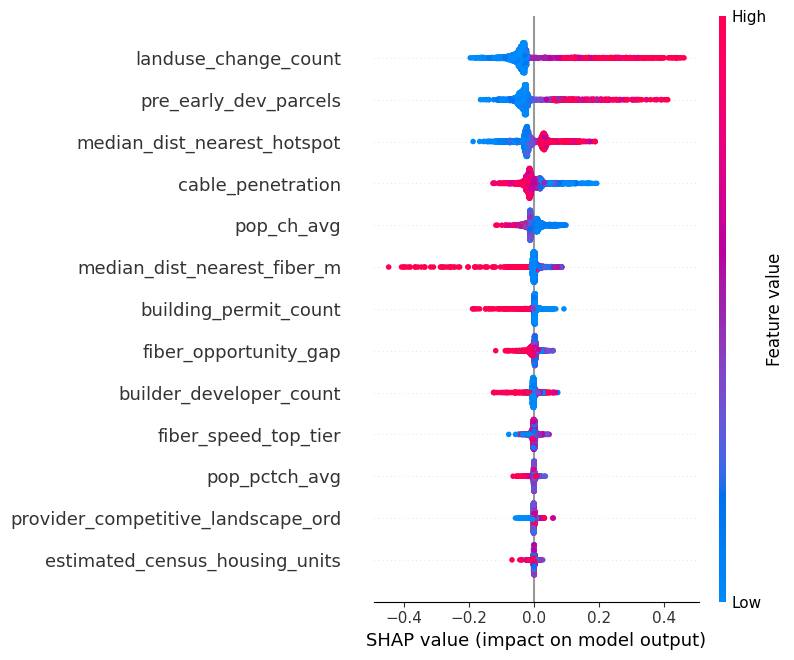


--- Cluster 3 — Top features by mean |SHAP| ---
fiber_opportunity_gap                 0.1279
median_dist_nearest_hotspot           0.1115
cable_penetration                     0.0661
fiber_speed_top_tier                  0.0518
pre_early_dev_parcels                 0.0330
pop_ch_avg                            0.0305
builder_developer_count               0.0266
estimated_census_housing_units        0.0197
pop_pctch_avg                         0.0178
landuse_change_count                  0.0123
building_permit_count                 0.0117
median_dist_nearest_fiber_m           0.0089
provider_competitive_landscape_ord    0.0067



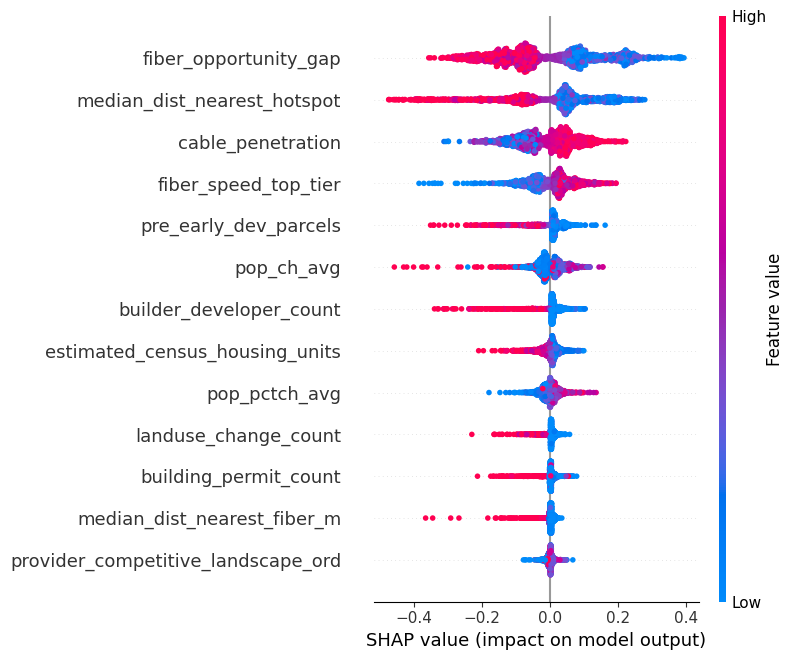


--- Cluster 4 — Top features by mean |SHAP| ---
median_dist_nearest_hotspot           0.1439
fiber_opportunity_gap                 0.0542
fiber_speed_top_tier                  0.0521
landuse_change_count                  0.0242
pre_early_dev_parcels                 0.0234
pop_ch_avg                            0.0219
median_dist_nearest_fiber_m           0.0205
cable_penetration                     0.0146
pop_pctch_avg                         0.0133
provider_competitive_landscape_ord    0.0101
building_permit_count                 0.0067
builder_developer_count               0.0063
estimated_census_housing_units        0.0031



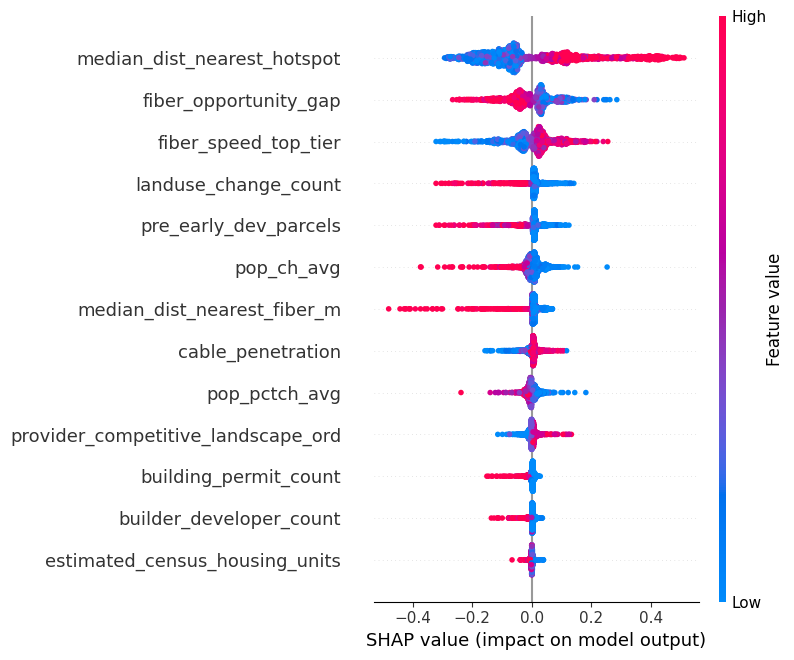


--- Cluster 5 — Top features by mean |SHAP| ---
median_dist_nearest_fiber_m           0.0786
median_dist_nearest_hotspot           0.0179
pop_ch_avg                            0.0088
cable_penetration                     0.0048
pre_early_dev_parcels                 0.0033
landuse_change_count                  0.0025
provider_competitive_landscape_ord    0.0018
fiber_opportunity_gap                 0.0016
builder_developer_count               0.0015
fiber_speed_top_tier                  0.0015
pop_pctch_avg                         0.0013
building_permit_count                 0.0009
estimated_census_housing_units        0.0008



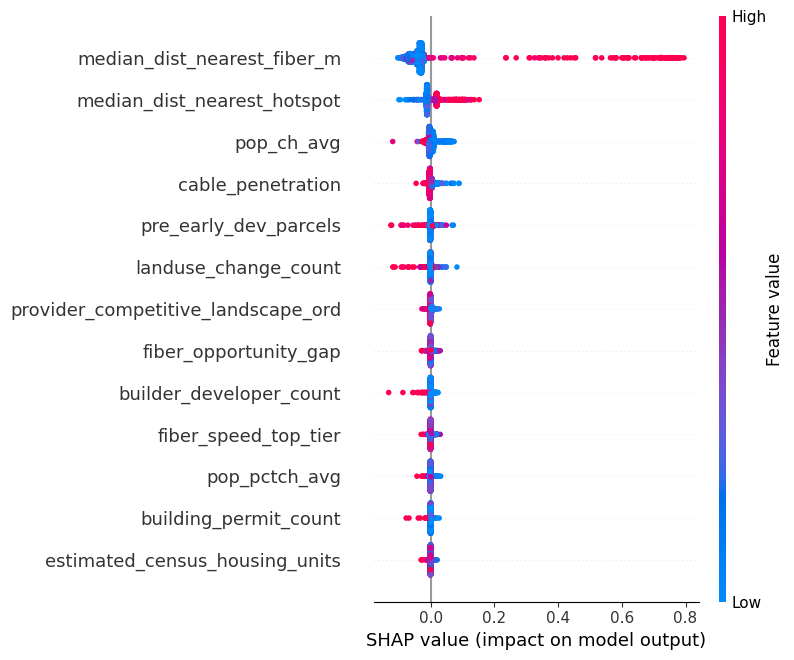


--- Cluster 6 — Top features by mean |SHAP| ---
fiber_opportunity_gap                 0.0880
median_dist_nearest_hotspot           0.0734
cable_penetration                     0.0689
provider_competitive_landscape_ord    0.0598
pop_ch_avg                            0.0394
estimated_census_housing_units        0.0310
fiber_speed_top_tier                  0.0303
pre_early_dev_parcels                 0.0292
builder_developer_count               0.0223
landuse_change_count                  0.0191
pop_pctch_avg                         0.0190
median_dist_nearest_fiber_m           0.0136
building_permit_count                 0.0059



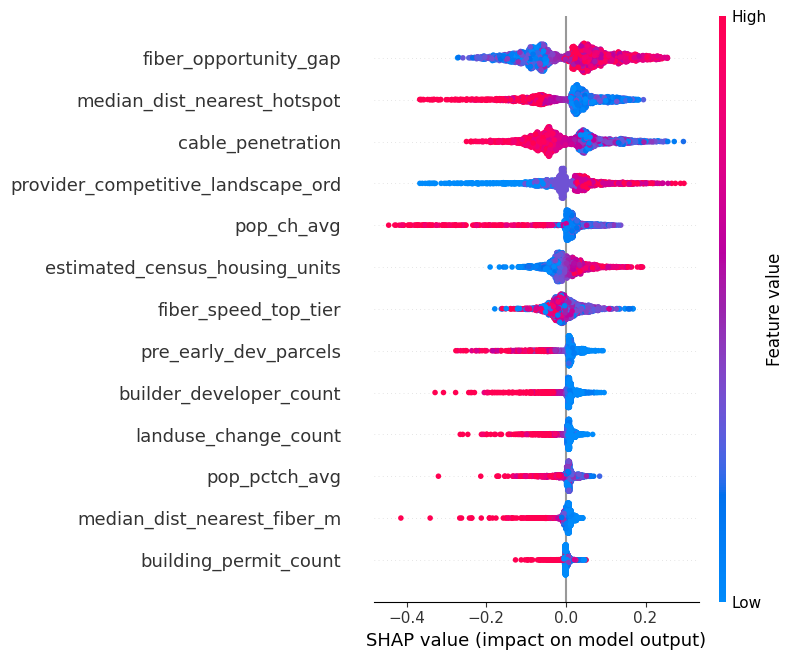


--- Cluster 7 — Top features by mean |SHAP| ---
builder_developer_count               0.0748
pre_early_dev_parcels                 0.0609
building_permit_count                 0.0410
median_dist_nearest_hotspot           0.0374
pop_pctch_avg                         0.0162
pop_ch_avg                            0.0153
estimated_census_housing_units        0.0119
cable_penetration                     0.0078
landuse_change_count                  0.0076
provider_competitive_landscape_ord    0.0052
fiber_opportunity_gap                 0.0051
fiber_speed_top_tier                  0.0049
median_dist_nearest_fiber_m           0.0039



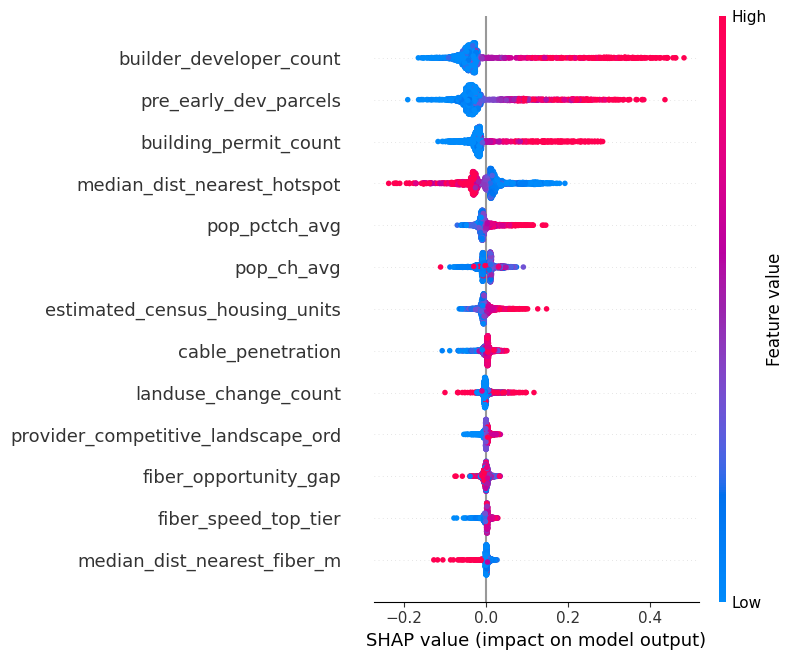

In [13]:
cluster_labels_sorted = sorted(y.unique())

# Convert 3D array (samples, features, classes) to list of per-class arrays
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_by_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_by_class = shap_values

for idx, cluster_id in enumerate(cluster_labels_sorted):
    mean_abs_shap = np.abs(shap_by_class[idx]).mean(axis=0)
    importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
    print(f"\n--- Cluster {cluster_id} — Top features by mean |SHAP| ---")
    print(importance.round(4).to_string())
    print()

    shap.summary_plot(shap_by_class[idx], X_shap, feature_names=feature_cols, 
                      title=f"Cluster {cluster_id}", show=True)

In [14]:
shap_importance = pd.DataFrame(
    {f"Cluster {c}": np.abs(shap_by_class[i]).mean(axis=0) 
     for i, c in enumerate(cluster_labels_sorted)},
    index=feature_cols
)
shap_importance['Global'] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values('Global', ascending=False)

with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4f}'.format):
    print(shap_importance.to_string())

                                    Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6  Cluster 7  Global
median_dist_nearest_hotspot            0.0293     0.0045     0.0378     0.1115     0.1439     0.0179     0.0734     0.0374  0.0570
fiber_opportunity_gap                  0.0870     0.0171     0.0083     0.1279     0.0542     0.0016     0.0880     0.0051  0.0486
fiber_speed_top_tier                   0.1063     0.0089     0.0049     0.0518     0.0521     0.0015     0.0303     0.0049  0.0326
cable_penetration                      0.0384     0.0243     0.0258     0.0661     0.0146     0.0048     0.0689     0.0078  0.0313
pop_ch_avg                             0.0197     0.0911     0.0196     0.0305     0.0219     0.0088     0.0394     0.0153  0.0308
pre_early_dev_parcels                  0.0247     0.0091     0.0575     0.0330     0.0234     0.0033     0.0292     0.0609  0.0302
provider_competitive_landscape_ord     0.0784     0.0040     0.0026     0.0067     